<a href="https://colab.research.google.com/github/Purva1204/DL_LAB_assignments/blob/main/Assignment-5/Assignment_5_RNN_LSTM_GRU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense

In [ ]:

vocab_size = 10000


(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("First review:", X_train[0])
print("First label:", y_train[0])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training samples: 25000
Testing samples: 25000
First review: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5,

In [ ]:

max_length = 200

X_train = pad_sequences(
    X_train,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_test = pad_sequences(
    X_test,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (25000, 200)
Testing shape: (25000, 200)


In [ ]:
def create_rnn_model():
    model = Sequential([
        Embedding(vocab_size, 32),
        SimpleRNN(32),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
rnn_model = create_rnn_model()

rnn_history = rnn_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.5023 - loss: 0.6941 - val_accuracy: 0.5064 - val_loss: 0.6934
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.6011 - loss: 0.6611 - val_accuracy: 0.5042 - val_loss: 0.7087
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.7049 - loss: 0.5270 - val_accuracy: 0.4954 - val_loss: 0.8045
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.7773 - loss: 0.3968 - val_accuracy: 0.4916 - val_loss: 0.9161
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.8130 - loss: 0.3481 - val_accuracy: 0.4980 - val_loss: 1.0149


In [ ]:
rnn_loss, rnn_accuracy = rnn_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("RNN Test Accuracy:", round(rnn_accuracy * 100, 2), "%")
print("RNN Test Loss:", round(rnn_loss, 4))

RNN Test Accuracy: 50.68 %
RNN Test Loss: 0.9874


In [ ]:
def create_lstm_model():
    model = Sequential([
        Embedding(vocab_size, 32),
        LSTM(32),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
lstm_model = create_lstm_model()

lstm_history = lstm_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step - accuracy: 0.5371 - loss: 0.6852 - val_accuracy: 0.6092 - val_loss: 0.6704
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 79ms/step - accuracy: 0.5325 - loss: 0.6889 - val_accuracy: 0.5526 - val_loss: 0.6858
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 85ms/step - accuracy: 0.6556 - loss: 0.6327 - val_accuracy: 0.6362 - val_loss: 0.6374
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 84ms/step - accuracy: 0.5907 - loss: 0.6522 - val_accuracy: 0.6134 - val_loss: 0.6373
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 83ms/step - accuracy: 0.6298 - loss: 0.6357 - val_accuracy: 0.5340 - val_loss: 0.6867


In [ ]:
lstm_loss, lstm_accuracy = lstm_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("LSTM Test Accuracy:", round(lstm_accuracy * 100, 2), "%")
print("LSTM Test Loss:", round(lstm_loss, 4))

LSTM Test Accuracy: 53.89 %
LSTM Test Loss: 0.6861


In [ ]:
def create_gru_model():
    model = Sequential([
        Embedding(vocab_size, 32),
        GRU(32),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
gru_model = create_gru_model()

gru_history = gru_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 105ms/step - accuracy: 0.5120 - loss: 0.6926 - val_accuracy: 0.5120 - val_loss: 0.6915
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 111ms/step - accuracy: 0.5580 - loss: 0.6948 - val_accuracy: 0.5332 - val_loss: 0.6864
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 106ms/step - accuracy: 0.6026 - loss: 0.6545 - val_accuracy: 0.5904 - val_loss: 0.6750
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 116ms/step - accuracy: 0.6866 - loss: 0.5754 - val_accuracy: 0.7694 - val_loss: 0.5499
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 121ms/step - accuracy: 0.6738 - loss: 0.5836 - val_accuracy: 0.7886 - val_loss: 0.4871


In [ ]:
gru_loss, gru_accuracy = gru_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("GRU Test Accuracy:", round(gru_accuracy * 100, 2), "%")
print("GRU Test Loss:", round(gru_loss, 4))

GRU Test Accuracy: 77.9 %
GRU Test Loss: 0.4975


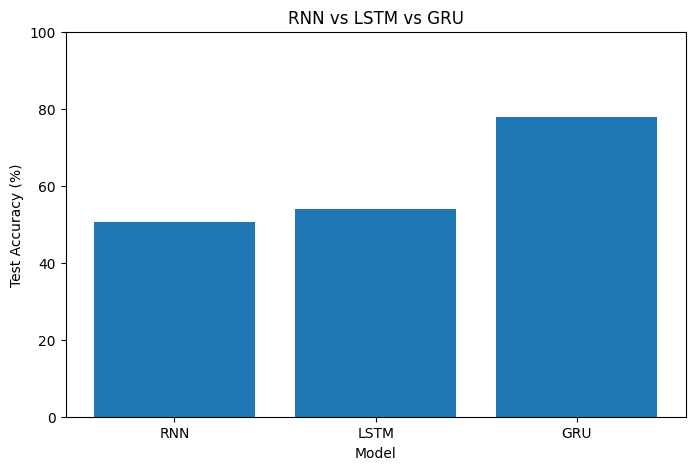

In [ ]:
models = ['RNN', 'LSTM', 'GRU']

accuracies = [
    rnn_accuracy * 100,
    lstm_accuracy * 100,
    gru_accuracy * 100
]

plt.figure(figsize=(8, 5))

plt.bar(models, accuracies)

plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.title("RNN vs LSTM vs GRU")
plt.ylim(0, 100)

plt.show()

In [ ]:
print("========== MODEL COMPARISON ==========")

print(
    "RNN  - Accuracy:",
    round(rnn_accuracy * 100, 2),
    "% | Loss:",
    round(rnn_loss, 4)
)

print(
    "LSTM - Accuracy:",
    round(lstm_accuracy * 100, 2),
    "% | Loss:",
    round(lstm_loss, 4)
)

print(
    "GRU  - Accuracy:",
    round(gru_accuracy * 100, 2),
    "% | Loss:",
    round(gru_loss, 4)
)

========== MODEL COMPARISON ==========
RNN  - Accuracy: 50.68 % | Loss: 0.9874
LSTM - Accuracy: 53.89 % | Loss: 0.6861
GRU  - Accuracy: 77.9 % | Loss: 0.4975


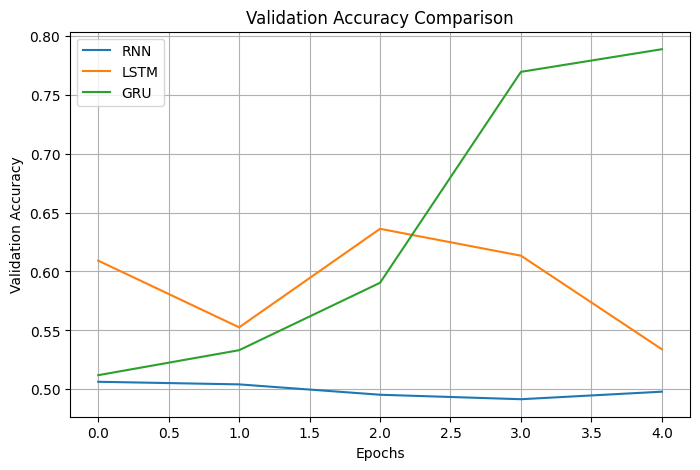

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    rnn_history.history['val_accuracy'],
    label='RNN'
)

plt.plot(
    lstm_history.history['val_accuracy'],
    label='LSTM'
)

plt.plot(
    gru_history.history['val_accuracy'],
    label='GRU'
)

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.grid(True)

plt.show()